# 1D-CNN for Human Activity Recognition

This notebook implements and evaluates a 1D Convolutional Neural Network (1D-CNN)
for Human Activity Recognition using the UCI Human Activity Recognition Using
Smartphones dataset.

The experiment follows the group's common preprocessing pipeline and uses the
preprocessed dataset stored in `processed_Data/har_processed.npz`.

The 1D-CNN experiment consists of multiple candidate CNN configurations.
Candidate models are trained using the training set and compared using the
validation set. The test set is kept completely unseen during model selection
and is used only for the final evaluation of the selected model.

The experiment evaluates predictive performance, generalization, model
complexity, training efficiency, inference efficiency, and training behaviour.

## 1. Imports and Reproducibility

The experiment uses fixed random seeds to improve reproducibility across model
training runs.

The random seed is fixed before loading and training models. No test-set
information is used during model development or candidate selection.

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.21.0
Random seed: 42


## 2. Load Preprocessed Data

The common preprocessing pipeline has already performed the required preprocessing
and generated `har_processed.npz`.

The CNN uses this processed data directly. No additional normalization or
data splitting is performed in this notebook.

The dataset contains separate training, validation, and test sets:

- Training set: used to train candidate models
- Validation set: used for candidate comparison and model selection
- Test set: reserved exclusively for final evaluation

In [2]:
# Load the shared preprocessed dataset
data_path = "../processed_Data/har_processed.npz"

data = np.load(data_path)

# Input data
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Labels
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# Metadata
activity_names = data["activity_names"]
signal_names = data["signal_names"]

print("Data loaded successfully.")
print()
print("Training data   :", X_train.shape)
print("Validation data :", X_val.shape)
print("Test data       :", X_test.shape)
print()
print("Activities:", activity_names)
print("Signals:", signal_names)

Data loaded successfully.

Training data   : (5551, 128, 9)
Validation data : (1801, 128, 9)
Test data       : (2947, 128, 9)

Activities: ['Walking' 'Walking Upstairs' 'Walking Downstairs' 'Sitting' 'Standing'
 'Laying']
Signals: ['body_acc_x' 'body_acc_y' 'body_acc_z' 'body_gyro_x' 'body_gyro_y'
 'body_gyro_z' 'total_acc_x' 'total_acc_y' 'total_acc_z']


## 3. Verify Dataset Structure

The 1D-CNN expects each sample to preserve its temporal structure.

Each sample contains:

- 128 time steps
- 9 sensor signals

Therefore, the CNN input shape is `(128, 9)`.

The problem is a six-class classification task.

In [3]:
# Expected dimensions
EXPECTED_TIMESTEPS = 128
EXPECTED_FEATURES = 9
EXPECTED_CLASSES = 6

assert X_train.shape[1:] == (EXPECTED_TIMESTEPS, EXPECTED_FEATURES)
assert X_val.shape[1:] == (EXPECTED_TIMESTEPS, EXPECTED_FEATURES)
assert X_test.shape[1:] == (EXPECTED_TIMESTEPS, EXPECTED_FEATURES)

assert len(np.unique(y_train)) == EXPECTED_CLASSES
assert len(np.unique(y_val)) == EXPECTED_CLASSES
assert len(np.unique(y_test)) == EXPECTED_CLASSES

print("Input shape:", X_train.shape[1:])
print("Number of classes:", EXPECTED_CLASSES)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

print("\nData structure verification: PASSED")

Input shape: (128, 9)
Number of classes: 6
Training samples: 5551
Validation samples: 1801
Test samples: 2947

Data structure verification: PASSED


## 4. Activity Labels

The dataset contains six human activity classes.

The integer labels are mapped to their corresponding activity names using the
metadata stored in the processed dataset.

In [4]:
print("Activity label mapping:\n")

for label, activity in enumerate(activity_names):
    print(f"{label}: {activity}")

print("\nTraining class distribution:\n")

train_class_counts = pd.Series(y_train).value_counts().sort_index()

for label, count in train_class_counts.items():
    print(f"{label} - {activity_names[label]}: {count}")

Activity label mapping:

0: Walking
1: Walking Upstairs
2: Walking Downstairs
3: Sitting
4: Standing
5: Laying

Training class distribution:

0 - Walking: 888
1 - Walking Upstairs: 797
2 - Walking Downstairs: 744
3 - Sitting: 993
4 - Standing: 1053
5 - Laying: 1076


## 5. Experimental Configuration

The candidate CNN architectures will be compared under controlled training
conditions.

The main experimental variable will be the CNN architecture/capacity.

The following conditions will remain consistent across candidates:

- Same training data
- Same validation data
- Same preprocessing
- Same loss function
- Same optimizer configuration
- Same batch size
- Same maximum number of epochs
- Same callback strategy
- Same random seed

The test set will not be used during candidate selection.

Exact CNN architecture parameters such as filter counts, kernel sizes and
number of convolutional blocks will be defined in the model-design phase.

In [5]:
# Experiment-level configuration
SEED = 42

# Data dimensions
INPUT_SHAPE = X_train.shape[1:]
NUM_CLASSES = len(activity_names)

# Candidate selection
PRIMARY_SELECTION_METRIC = "val_loss"

# Test set policy
TEST_USED_DURING_SELECTION = False

print("Experiment configuration")
print("------------------------")
print("Random seed:", SEED)
print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Primary selection metric:", PRIMARY_SELECTION_METRIC)
print("Test used during candidate selection:", TEST_USED_DURING_SELECTION)

Experiment configuration
------------------------
Random seed: 42
Input shape: (128, 9)
Number of classes: 6
Primary selection metric: val_loss
Test used during candidate selection: False


## 6. Candidate Evaluation Records

For each CNN candidate, the experiment will record both predictive and
computational characteristics.

### Predictive performance
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Training behaviour
- Training loss
- Validation loss
- Training accuracy
- Validation accuracy
- Number of epochs completed

### Model complexity
- Total parameters
- Trainable parameters

### Computational efficiency
- Training time
- Inference time

These measurements will support candidate selection and the later analysis of
generalization, model complexity, computational cost, convergence and errors.

In [6]:
candidate_results = []

print("Candidate result structure initialized.")
print("Results will be added after the CNN candidates are implemented.")

Candidate result structure initialized.
Results will be added after the CNN candidates are implemented.


## 7. Model Selection and Final Evaluation Protocol

The CNN experiment follows a two-stage evaluation process.

### Stage 1 — Candidate development and selection

Each candidate CNN is trained using the training set.

The validation set is used to:

- monitor training behaviour
- compare candidate architectures
- identify overfitting or underfitting
- select the final CNN architecture

The test set is not used during this stage.

### Stage 2 — Final evaluation

After the final CNN architecture and training configuration have been selected,
the test set is used for the final evaluation.

The final test results are reported separately from the validation results.

This prevents the test data from influencing model selection.

In [7]:
# Explicit experiment split policy
EXPERIMENT_SPLITS = {
    "training": "Used for model fitting",
    "validation": "Used for candidate comparison and model selection",
    "test": "Reserved for final evaluation only"
}

for split, purpose in EXPERIMENT_SPLITS.items():
    print(f"{split.capitalize():12} -> {purpose}")

Training     -> Used for model fitting
Validation   -> Used for candidate comparison and model selection
Test         -> Reserved for final evaluation only


## 6. CNN Candidate Architecture Design

Three 1D-CNN candidates are evaluated to investigate the effect of increasing
temporal feature-extraction capacity.

The candidates differ primarily in the number of convolutional blocks and the
number of filters. This provides a controlled comparison of model capacity
while keeping the main convolutional design consistent.

### CNN-Small
A lightweight model containing one convolutional block with 32 filters.
This provides a low-complexity baseline for determining whether a relatively
simple temporal CNN can learn useful activity patterns.

### CNN-Medium
A two-block CNN using 32 and 64 filters. The second convolutional block
allows the model to learn higher-level temporal representations from features
extracted by the first block.

### CNN-Large
A three-block CNN using 32, 64 and 128 filters. This provides greater
hierarchical feature-extraction capacity and allows us to investigate whether
additional capacity provides useful improvements or introduces unnecessary
complexity.

For all candidates:

- Input shape: `(128, 9)`
- Kernel size: `5`
- Activation: ReLU
- Batch Normalization follows each convolution
- MaxPooling1D with pool size `2`
- Global Average Pooling is used before the dense classification head
- The output layer contains 6 neurons for the six activity classes

The test set is not used when comparing these candidate architectures.

In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    ReLU,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)


# Common CNN configuration
KERNEL_SIZE = 5
POOL_SIZE = 2
DENSE_UNITS = 64
DROPOUT_RATE = 0.3


def build_cnn_candidate(filters, name):
    """
    Build a 1D-CNN candidate.

    Parameters
    ----------
    filters : list of int
        Number of filters for each convolutional block.
    name : str
        Name assigned to the model.

    Returns
    -------
    tf.keras.Model
        Uncompiled CNN model.
    """

    model = Sequential(name=name)

    # Input
    model.add(Input(shape=INPUT_SHAPE))

    # Convolutional feature-extraction blocks
    for i, num_filters in enumerate(filters, start=1):

        model.add(
            Conv1D(
                filters=num_filters,
                kernel_size=KERNEL_SIZE,
                padding="same",
                name=f"conv1d_{i}"
            )
        )

        model.add(
            BatchNormalization(
                name=f"batch_norm_{i}"
            )
        )

        model.add(
            ReLU(
                name=f"relu_{i}"
            )
        )

        model.add(
            MaxPooling1D(
                pool_size=POOL_SIZE,
                name=f"max_pool_{i}"
            )
        )

    # Classification head
    model.add(
        GlobalAveragePooling1D(
            name="global_average_pooling"
        )
    )

    model.add(
        Dense(
            DENSE_UNITS,
            activation="relu",
            name="dense"
        )
    )

    model.add(
        Dropout(
            DROPOUT_RATE,
            name="dropout"
        )
    )

    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax",
            name="output"
        )
    )

    return model


# Define the three candidate architectures
cnn_small = build_cnn_candidate(
    filters=[32],
    name="CNN_Small"
)

cnn_medium = build_cnn_candidate(
    filters=[32, 64],
    name="CNN_Medium"
)

cnn_large = build_cnn_candidate(
    filters=[32, 64, 128],
    name="CNN_Large"
)

print("CNN candidate architectures created successfully.")

CNN candidate architectures created successfully.


## 7. Candidate Architecture Inspection

Before training the models, their structures and parameter counts are inspected.

Parameter counts provide an initial measure of model complexity and will later
be considered alongside predictive performance and computational efficiency.

In [10]:
models = {
    "CNN-Small": cnn_small,
    "CNN-Medium": cnn_medium,
    "CNN-Large": cnn_large
}

for name, model in models.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    model.summary()
    print()

CNN-Small


Model: "CNN_Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling1D)       │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,102 (16.02 KB)

 Trainable params: 4,038 (15.77 KB)

...

Model: "CNN_Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling1D)       │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (ReLU)                   │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling1D)       │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 32, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (ReLU)                   │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling1D)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,406 (243.77 KB)

 Trainable params: 61,958 (242.02 KB)

 Non-trainable params: 448 (1.75 KB)

## 8. Training Configuration

All CNN candidates are trained using the same optimization and training
configuration to support a fair architectural comparison.

### Loss Function

Sparse categorical cross-entropy is used because the target labels are
represented as integer class indices for the six activity classes.

### Optimizer

Adam is used with an initial learning rate of `0.001`. Adam provides adaptive
parameter-wise learning rates and is suitable for training the convolutional
networks used in this experiment.

### Batch Size

A batch size of `64` is used for all candidate models. Keeping the batch size
constant prevents the training configuration from becoming a confounding
factor when comparing architectures.

### Training Duration

Each candidate can train for a maximum of `100` epochs. The actual number of
epochs may be lower because EarlyStopping is used.

### Early Stopping

EarlyStopping monitors validation loss with a patience of `10` epochs and
restores the weights from the epoch with the best validation loss.

### Learning-Rate Scheduling

ReduceLROnPlateau monitors validation loss. If validation loss stops improving
for `5` epochs, the learning rate is reduced by a factor of `0.5`.

The validation set is used for monitoring and training-control decisions.
The test set is not used during training or candidate selection.

In [11]:
# Common training configuration for all CNN candidates

LEARNING_RATE = 0.001
BATCH_SIZE = 64
MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10

LR_REDUCTION_FACTOR = 0.5
LR_REDUCTION_PATIENCE = 5
MIN_LEARNING_RATE = 1e-6

print("Training configuration")
print("----------------------")
print("Optimizer        : Adam")
print("Learning rate    :", LEARNING_RATE)
print("Loss             : Sparse Categorical Cross-Entropy")
print("Batch size       :", BATCH_SIZE)
print("Maximum epochs   :", MAX_EPOCHS)
print("Early stopping   : patience =", EARLY_STOPPING_PATIENCE)
print("LR reduction     : factor =", LR_REDUCTION_FACTOR)
print("LR patience      :", LR_REDUCTION_PATIENCE)
print("Minimum LR       :", MIN_LEARNING_RATE)

Training configuration
----------------------
Optimizer        : Adam
Learning rate    : 0.001
Loss             : Sparse Categorical Cross-Entropy
Batch size       : 64
Maximum epochs   : 100
Early stopping   : patience = 10
LR reduction     : factor = 0.5
LR patience      : 5
Minimum LR       : 1e-06


## 9. Model Compilation

The three candidate architectures are compiled using the same loss function and
optimizer configuration.

Only the CNN architecture varies between candidates. This keeps the comparison
focused on the effect of model capacity.

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy


def compile_model(model):
    """
    Compile a CNN candidate using the common training configuration.
    """
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    
    return model


# Compile all candidates
cnn_small = compile_model(cnn_small)
cnn_medium = compile_model(cnn_medium)
cnn_large = compile_model(cnn_large)

print("All CNN candidates compiled successfully.")

All CNN candidates compiled successfully.


In [13]:
for name, model in models.items():
    print(f"{name}:")
    print("  Loss:", model.loss)
    print("  Optimizer:", type(model.optimizer).__name__)
    print("  Learning rate:", float(model.optimizer.learning_rate.numpy()))
    print()

CNN-Small:
  Loss: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x000001D7C2C787C0>, kwargs={'from_logits': False, 'ignore_class': None, 'axis': -1})>
  Optimizer: Adam
  Learning rate: 0.0010000000474974513

CNN-Medium:
  Loss: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x000001D7C2C787C0>, kwargs={'from_logits': False, 'ignore_class': None, 'axis': -1})>
  Optimizer: Adam
  Learning rate: 0.0010000000474974513

CNN-Large:
  Loss: <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x000001D7C2C787C0>, kwargs={'from_logits': False, 'ignore_class': None, 'axis': -1})>
  Optimizer: Adam
  Learning rate: 0.0010000000474974513



## 10. Training Callbacks

Two validation-based callbacks are used during candidate training.

### EarlyStopping

Training stops when validation loss has not improved for the specified
patience period. The weights from the best validation-loss epoch are restored.

### ReduceLROnPlateau

When validation loss reaches a plateau, the learning rate is reduced by a
factor of 0.5. This allows the optimizer to make smaller parameter updates
when further improvement becomes difficult.

Both callbacks monitor validation loss. The test set is not involved in
training or model selection.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def create_callbacks():
    """
    Create fresh callbacks for each CNN candidate.
    """

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=LR_REDUCTION_FACTOR,
        patience=LR_REDUCTION_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
        verbose=1
    )

    return [early_stopping, reduce_lr]


print("Callback factory created successfully.")

Callback factory created successfully.


## 11. Candidate Training Function

A common training function is used for all CNN candidates to ensure that the
training procedure remains consistent.

For each candidate, the function:

- trains using the training set;
- evaluates during training using the validation set;
- applies the same callbacks;
- measures training time;
- records the number of epochs completed;
- identifies the epoch with the best validation loss;
- records the corresponding validation performance;
- stores the complete training history.

The test set is not passed to this function.

In [15]:
def train_candidate(model, model_name):
    """
    Train one CNN candidate using the common experimental configuration.

    Parameters
    ----------
    model : tf.keras.Model
        Compiled CNN candidate.
    model_name : str
        Name of the candidate model.

    Returns
    -------
    model : tf.keras.Model
        Trained model with the best validation-loss weights restored.
    history : tf.keras.callbacks.History
        Training history.
    training_time : float
        Training duration in seconds.
    results : dict
        Summary of training results.
    """

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    # Create fresh callbacks for this candidate
    callbacks = create_callbacks()

    # Measure training time
    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    end_time = time.perf_counter()

    training_time = end_time - start_time

    # Extract history
    history_dict = history.history

    # Best validation-loss epoch
    best_epoch_index = np.argmin(history_dict["val_loss"])
    best_epoch = best_epoch_index + 1

    results = {
        "model": model_name,
        "epochs_completed": len(history_dict["loss"]),
        "best_epoch": best_epoch,
        "best_val_loss": history_dict["val_loss"][best_epoch_index],
        "best_val_accuracy": history_dict["val_accuracy"][best_epoch_index],
        "final_train_loss": history_dict["loss"][-1],
        "final_train_accuracy": history_dict["accuracy"][-1],
        "final_val_loss": history_dict["val_loss"][-1],
        "final_val_accuracy": history_dict["val_accuracy"][-1],
        "training_time_seconds": training_time,
        "total_parameters": model.count_params()
    }

    print()
    print(f"{model_name} training completed.")
    print(f"Epochs completed : {results['epochs_completed']}")
    print(f"Best epoch       : {results['best_epoch']}")
    print(f"Best val loss    : {results['best_val_loss']:.4f}")
    print(f"Best val accuracy: {results['best_val_accuracy']:.4f}")
    print(f"Training time    : {training_time:.2f} seconds")
    print(f"Total parameters : {results['total_parameters']:,}")

    return model, history, training_time, results


print("Training function created successfully.")

Training function created successfully.


In [16]:
print("Training function is ready.")
print()
print("Candidates:")
for name in models:
    print("-", name)

print()
print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Test data is excluded from candidate training.")

Training function is ready.

Candidates:
- CNN-Small
- CNN-Medium
- CNN-Large

Training data: (5551, 128, 9)
Validation data: (1801, 128, 9)
Test data is excluded from candidate training.


## 12. Train CNN-Small

CNN-Small is the lightweight baseline architecture.

It contains a single convolutional feature-extraction block and is used to
establish how well a relatively low-capacity 1D-CNN can classify the six
human activities.

The model is trained using the common training configuration defined above.
The validation set is used for monitoring during training, while the test set
remains completely unused.

In [17]:
# Train CNN-Small

cnn_small, history_small, training_time_small, results_small = train_candidate(
    cnn_small,
    "CNN-Small"
)

Training: CNN-Small
Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6010 - loss: 1.1557 - val_accuracy: 0.8634 - val_loss: 0.8197 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8262 - loss: 0.5552 - val_accuracy: 0.9550 - val_loss: 0.3998 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8798 - loss: 0.3598 - val_accuracy: 0.9733 - val_loss: 0.2408 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9069 - loss: 0.2701 - val_accuracy: 0.9806 - val_loss: 0.1631 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9162 - loss: 0.2285 - val_accuracy: 0.9817 - val_loss: 0.1296 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9209 - loss: 0.2044 - val_accuracy: 0.9845 - val_loss: 0.1115 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9236 - lo

## 13. CNN-Small Training History

The training history is visualized using training and validation accuracy and
loss curves.

These curves are used to examine convergence and generalization behaviour,
including potential signs of overfitting or underfitting.

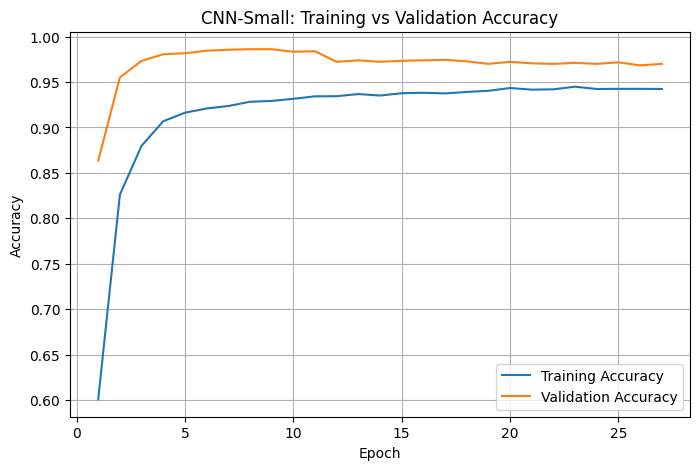

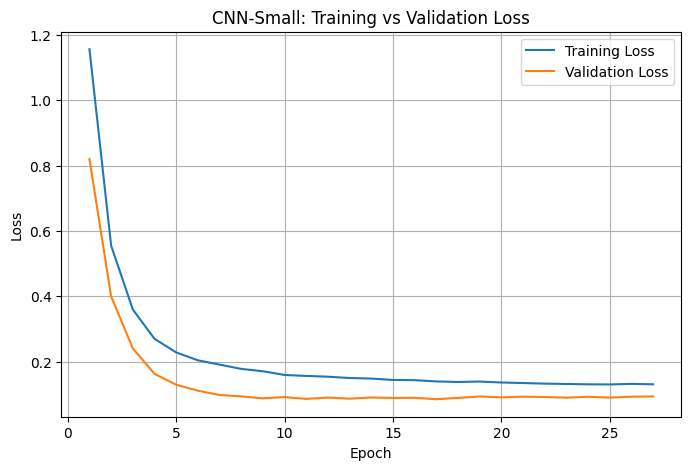

In [18]:
# Extract CNN-Small training history
history_small_dict = history_small.history

epochs_small = range(1, len(history_small_dict["loss"]) + 1)

# Accuracy curves
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_small,
    history_small_dict["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_small,
    history_small_dict["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-Small: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Loss curves
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_small,
    history_small_dict["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_small,
    history_small_dict["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-Small: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
print("CNN-Small training summary")
print("--------------------------")
print("Epochs completed:", len(history_small_dict["loss"]))
print("Best epoch:", results_small["best_epoch"])
print("Best validation loss:", results_small["best_val_loss"])
print("Best validation accuracy:", results_small["best_val_accuracy"])
print("Training time:", results_small["training_time_seconds"])

CNN-Small training summary
--------------------------
Epochs completed: 27
Best epoch: 17
Best validation loss: 0.08536975085735321
Best validation accuracy: 0.974458634853363
Training time: 13.589338199992198


## 14. Train CNN-Medium

CNN-Medium extends the lightweight CNN with a second convolutional feature
extraction block and increases the number of filters from 32 to 64.

The purpose of this candidate is to investigate whether additional hierarchical
temporal feature extraction improves validation performance compared with the
lightweight CNN.

The same training configuration and validation protocol used for CNN-Small are
applied to CNN-Medium.

In [20]:
# Train CNN-Medium

cnn_medium, history_medium, training_time_medium, results_medium = train_candidate(
    cnn_medium,
    "CNN-Medium"
)

Training: CNN-Medium
Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7501 - loss: 0.7398 - val_accuracy: 0.9928 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9175 - loss: 0.2438 - val_accuracy: 0.9950 - val_loss: 0.1507 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9236 - loss: 0.1842 - val_accuracy: 0.9850 - val_loss: 0.0979 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9315 - loss: 0.1599 - val_accuracy: 0.9789 - val_loss: 0.0932 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9364 - loss: 0.1527 - val_accuracy: 0.9722 - val_loss: 0.1002 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9380 - loss: 0.1466 - val_accuracy: 0.9717 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9397 - 